#                         Titanic Survival Prediction Model


# Objective 🎯

To predict the survival of passengers on the Titanic using machine learning models.

# Libraries Used 🧰

**Python 3.12 <br> Numpy <br> Pandas <br> Matplotlib <br> Seaborn <br> Scikit-learn <br> TensorFlow / Keras**

# WorkFlow 📊

1. Importing Libraries <br>
2. Data loading and overview <br>
3. Exploratory Data Analysis (EDA) <br> 
4. Data cleaning and preprocessing  <br>
5. Feature engineering  <br>
6. Model building (Logistic Regression, RandomForest, etc.) <br> 
7. Model evaluation and comparison <br>
8. Final model and submission file <br> 
9. Summary & conclusions

## Step 1. Importing Libraries

In [ ]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf


In [2]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

In [3]:
sns.set(style = 'whitegrid', context = 'notebook', font_scale = 1.1)
plt.rcParams['figure.figsize'] = (10, 6)

# Step 2. Load the Dataset

In [4]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [5]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

# Step 3. Exploratory Data Analysis

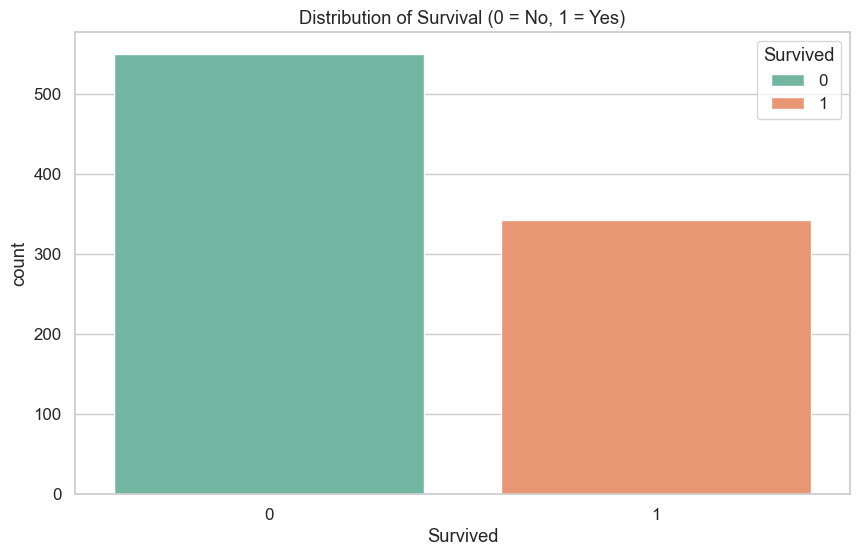

In [9]:
# Count of survived vs not survived
sns.countplot(x = 'Survived', data = train, hue = 'Survived', palette = 'Set2')
plt.title('Distribution of Survival (0 = No, 1 = Yes)')
plt.show()

In [10]:
# Percentage of survivors
survived_pct = train['Survived'].value_counts(normalize = True) * 100
print("Survival Percentage:\n", survived_pct)

Survival Percentage:
 Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


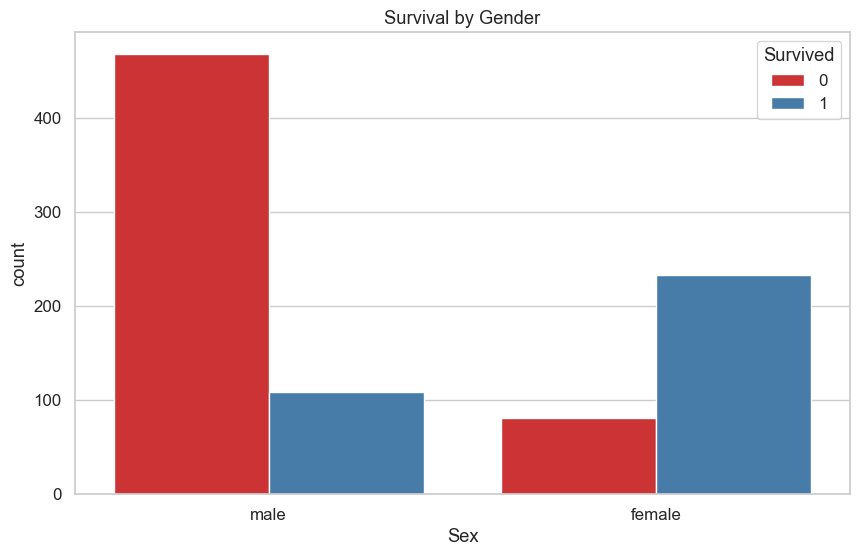

In [11]:
#Survival by Sex
sns.countplot(x = 'Sex', hue = 'Survived', data = train, palette = 'Set1')
plt.title('Survival by Gender')
plt.show()

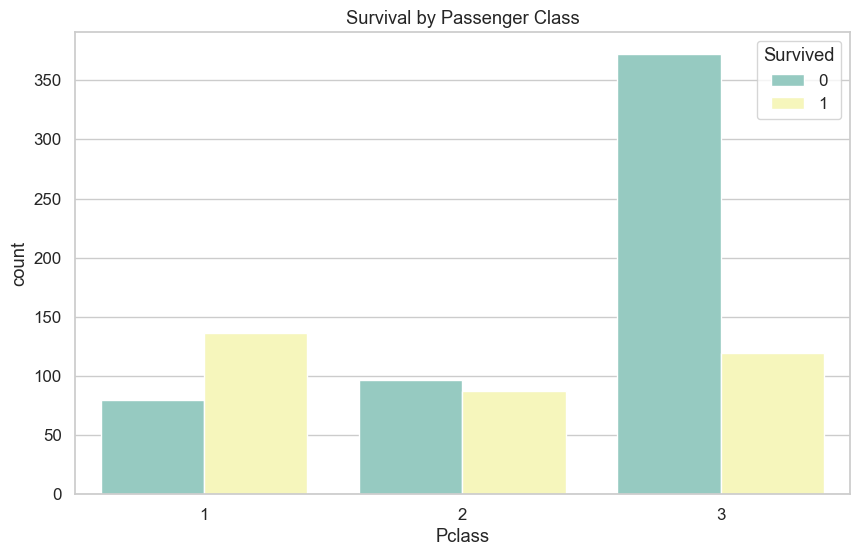

In [12]:
# Survival by Passsenger Class(Pclass)
sns.countplot(x = 'Pclass', hue = 'Survived', data = train, palette = 'Set3')
plt.title('Survival by Passenger Class')
plt.show()

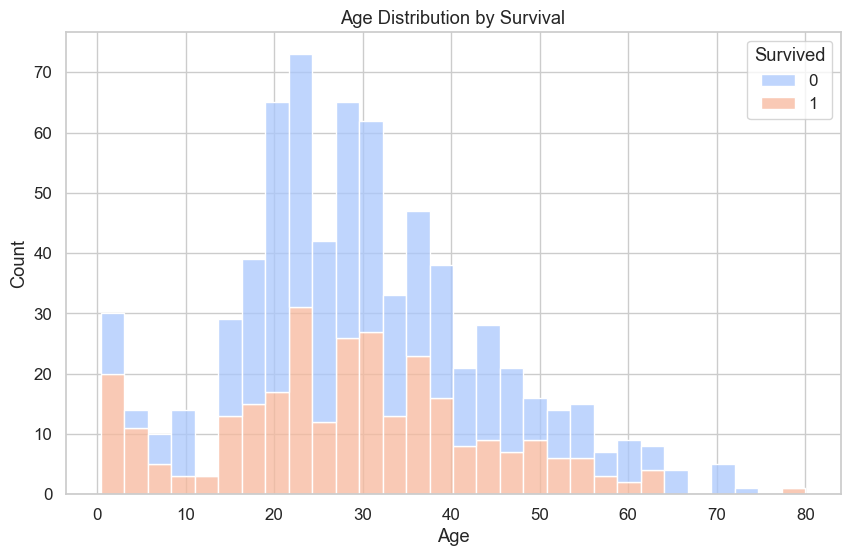

In [13]:
# Age distribution by survival
sns.histplot(data = train, x = 'Age', hue = 'Survived', multiple = 'stack', bins = 30, palette = 'coolwarm')
plt.title('Age Distribution by Survival')
plt.show()

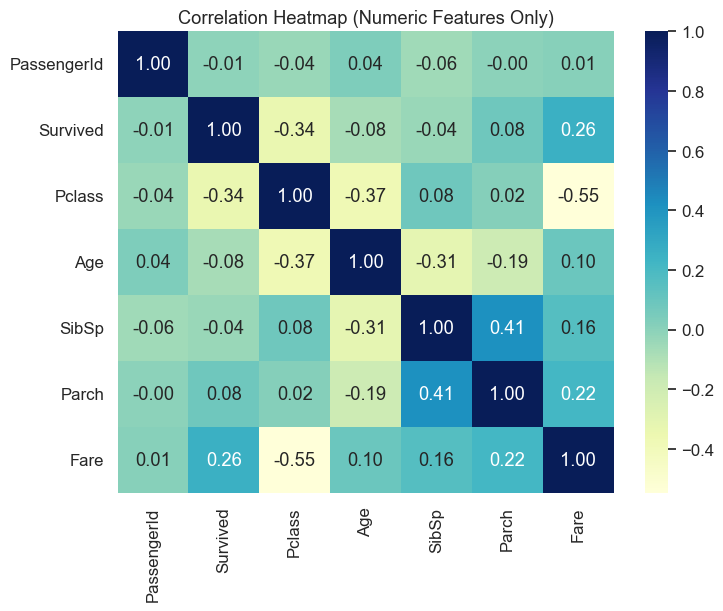

In [14]:
# Correlation heatmap
plt.figure(figsize = (8, 6))
numeric_features = train.select_dtypes(include = ['int64', 'float64'])
sns.heatmap(numeric_features.corr(), annot = True, cmap = 'YlGnBu', fmt = ".2f")
plt.title('Correlation Heatmap (Numeric Features Only)')
plt.show()

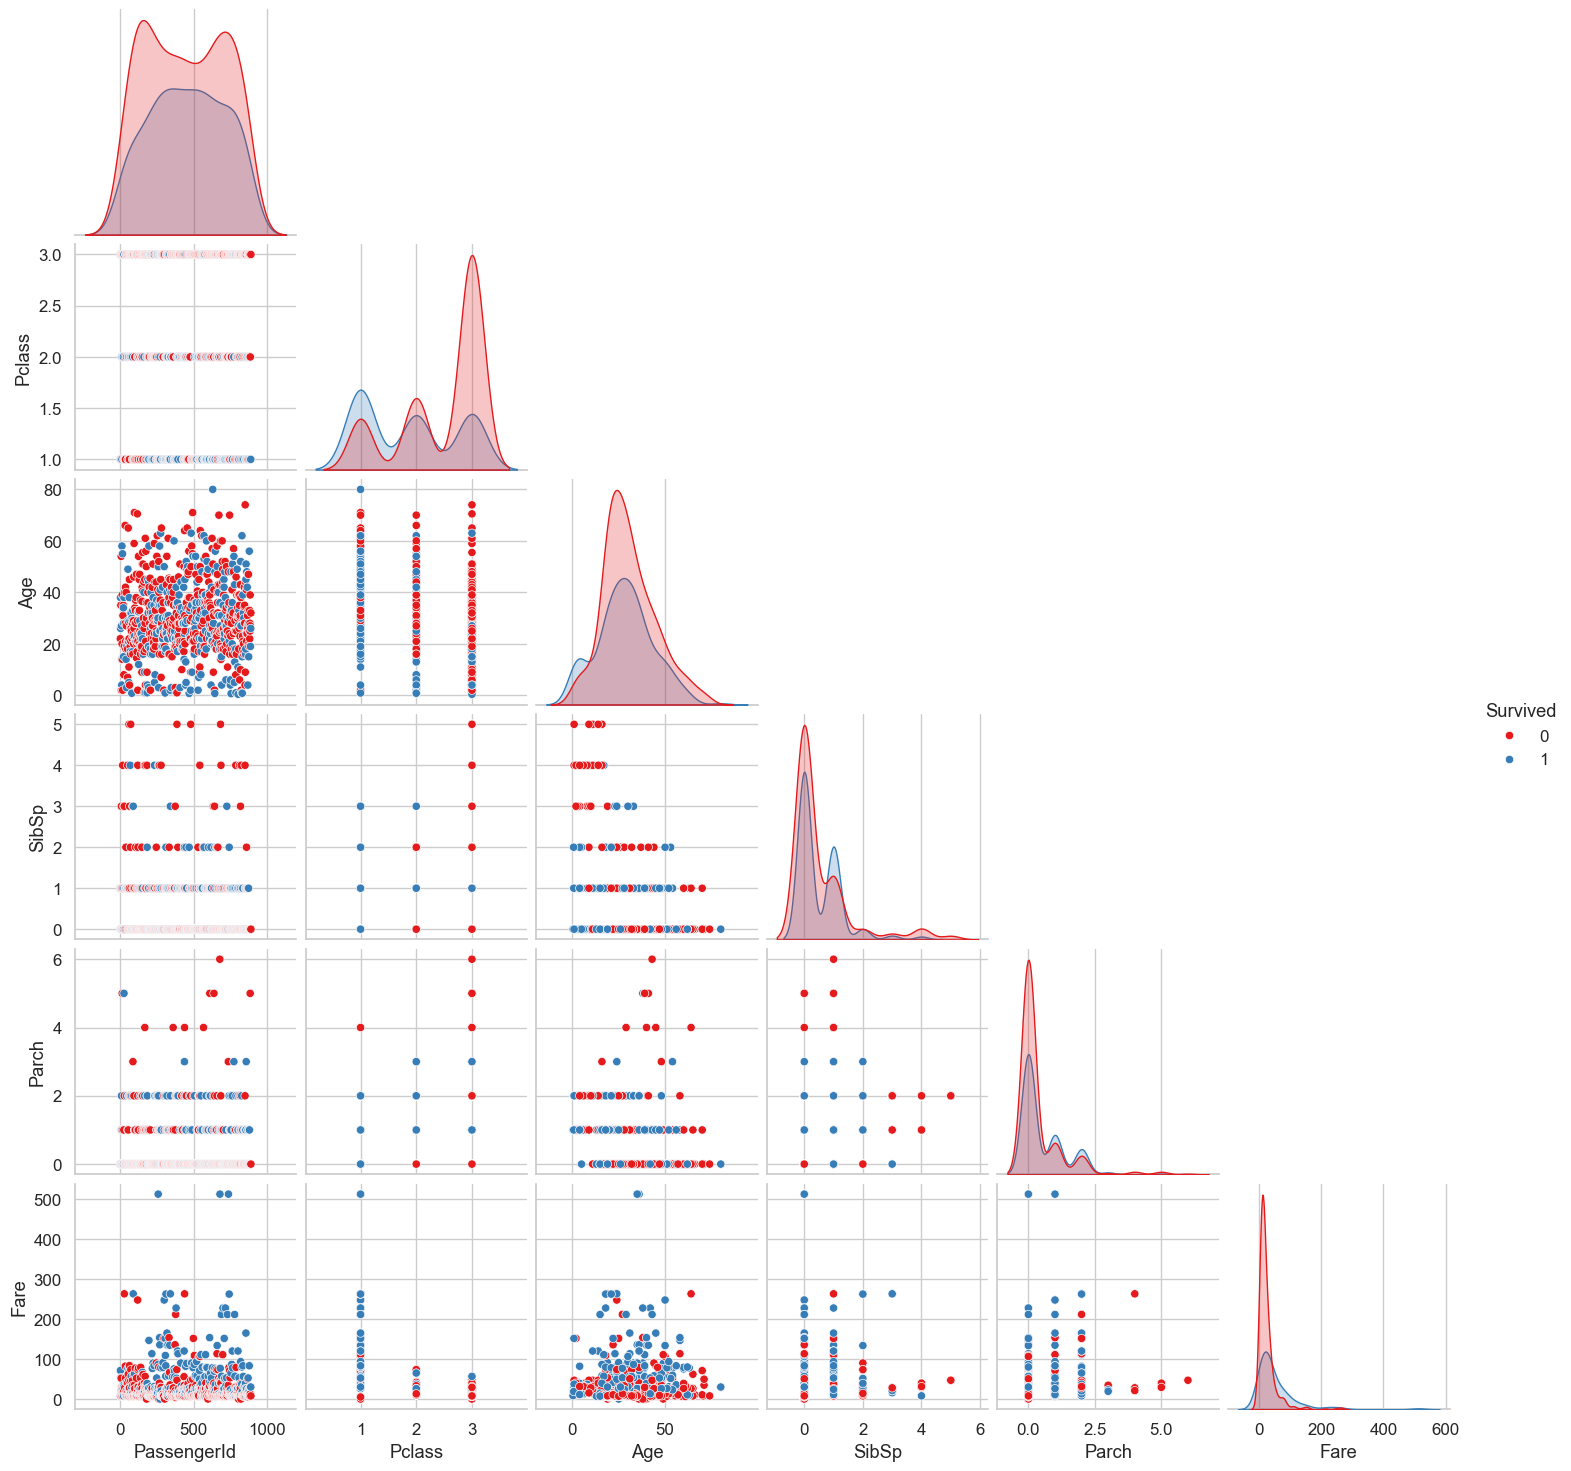

In [15]:
# Pairplot for Numeric Features
numeric_cols = train.select_dtypes(include = ['int64', 'float64']).columns.tolist()
if 'Survived' not in numeric_cols:
    numeric_cols.append('Survived')
pairplot_data = train[numeric_cols].dropna()

sns.pairplot(pairplot_data, hue = 'Survived', palette = 'Set1', corner = True)
plt.show()

# Step 4. Data cleaning and preprocessing

In [16]:
train_cleaned = train.copy()
test_cleaned = test.copy()

In [17]:
#view before cleaning
print("--- Train Dataset BEFORE Cleaning ---")
display(train.head())

--- Train Dataset BEFORE Cleaning ---


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [18]:
print("Missing values BEFORE Cleaning:")
print(train.isnull().sum())

Missing values BEFORE Cleaning:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [19]:
# Make copies
train_cleaned = train.copy()
test_cleaned = test.copy()

# Fill missing values without inplace
train_cleaned['Age'] = train_cleaned['Age'].fillna(train_cleaned['Age'].median())
test_cleaned['Age'] = test_cleaned['Age'].fillna(test_cleaned['Age'].median())

train_cleaned['Embarked'] = train_cleaned['Embarked'].fillna(train_cleaned['Embarked'].mode()[0])
test_cleaned['Embarked'] = test_cleaned['Embarked'].fillna(test_cleaned['Embarked'].mode()[0])

test_cleaned['Fare'] = test_cleaned['Fare'].fillna(test_cleaned['Fare'].median())

# Drop 'Cabin' (too many missing) and irrelevant columns
drop_cols = ['Cabin', 'PassengerId', 'Name', 'Ticket']
train_cleaned.drop(columns=drop_cols, inplace=True)
test_ids = test_cleaned['PassengerId']  # keep for submission
test_cleaned.drop(columns=drop_cols, inplace=True)

# Encode 'Sex'
train_cleaned['Sex'] = train_cleaned['Sex'].map({'male':0, 'female':1})
test_cleaned['Sex'] = test_cleaned['Sex'].map({'male':0, 'female':1})

# One-hot encode 'Embarked' and ensure train-test alignment
train_cleaned = pd.get_dummies(train_cleaned, columns=['Embarked'], drop_first=True)
test_cleaned = pd.get_dummies(test_cleaned, columns=['Embarked'], drop_first=True)

In [20]:
#View After Cleaning
print("--- Train Dataset AFTER Cleaning ---")
display(train_cleaned.head())

--- Train Dataset AFTER Cleaning ---


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,False,True
1,1,1,1,38.0,1,0,71.2833,False,False
2,1,3,1,26.0,0,0,7.9250,False,True
3,1,1,1,35.0,1,0,53.1000,False,True
4,0,3,0,35.0,0,0,8.0500,False,True


In [21]:
print("Missing values AFTER Cleaning:")
print(train_cleaned.isnull().sum())

Missing values AFTER Cleaning:
Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked_Q    0
Embarked_S    0
dtype: int64


# Step 5. Feature Engineering

In [22]:
train_fe = train_cleaned.copy()
test_fe = test_cleaned.copy()

In [26]:
# Make copies of cleaned datasets
train_fe = train_cleaned.copy()
test_fe = test_cleaned.copy()

# Family Size = SibSp + Parch + 1 (including self)
train_fe['FamilySize'] = train_fe['SibSp'] + train_fe['Parch'] + 1
test_fe['FamilySize'] = test_fe['SibSp'] + test_fe['Parch'] + 1

#  IsAlone = 1 if FamilySize == 1, else 0
train_fe['IsAlone'] = (train_fe['FamilySize'] == 1).astype(int)
test_fe['IsAlone'] = (test_fe['FamilySize'] == 1).astype(int)

#  Extract Title from Name (we need original 'train' and 'test' datasets with Name)
train_titles = train.copy()
test_titles = test.copy()
train_titles['Title'] = train_titles['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
test_titles['Title'] = test_titles['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# Simplify rare titles
rare_titles = train_titles['Title'].value_counts() < 10
train_titles['Title'] = train_titles['Title'].apply(lambda x: 'Rare' if rare_titles.get(x, False) else x)
test_titles['Title'] = test_titles['Title'].apply(lambda x: 'Rare' if rare_titles.get(x, False) else x)

# Encode 'Title' numerically
title_mapping = {title: idx for idx, title in enumerate(train_titles['Title'].unique())}
train_fe['Title'] = train_titles['Title'].map(title_mapping)
test_fe['Title'] = test_titles['Title'].map(title_mapping)

# Drop 'SibSp' and 'Parch' if you want to reduce redundancy
train_fe.drop(columns=['SibSp', 'Parch'], inplace=True)
test_fe.drop(columns=['SibSp', 'Parch'], inplace=True)

print("--- Feature Engineering Complete ---")
display(train_fe.head())


--- Feature Engineering Complete ---


,Survived,Pclass,Sex,Age,Fare,Embarked_Q,Embarked_S,FamilySize,IsAlone,Title
0,0,3,0,22.0,7.2500,False,True,2,0,0
1,1,1,1,38.0,71.2833,False,False,2,0,1
2,1,3,1,26.0,7.9250,False,True,1,1,2
3,1,1,1,35.0,53.1000,False,True,2,0,1
4,0,3,0,35.0,8.0500,False,True,1,1,0


In [27]:
print("\nNew Features Summary:")
print(train_fe[['FamilySize', 'IsAlone', 'Title']].head())


New Features Summary:
   FamilySize  IsAlone  Title
0           2        0      0
1           2        0      1
2           1        1      2
3           2        0      1
4           1        1      0


# Step 6. Split the dataset for modeling

In [28]:
# Let's assume after feature engineering, these are the features
final_features = [
    'Pclass', 'Sex', 'Age', 'Fare', 
    'Embarked_Q', 'Embarked_S', 
    'FamilySize', 'IsAlone', 'Title'
]
X = train_fe[final_features]
y = train_fe['Survived']

X_test_aligned = test_fe[final_features]


In [29]:
X = train_fe.drop(columns = ['Survived'])
y = train_fe['Survived']
X_test = test_fe.copy()

In [30]:
#Split into training and validation sets(80% train, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# X_test = test_fe.reindex(columns=X_train.columns, fill_value=0)

In [31]:
print("--- Data Split Completed ---")
print("Training set shape:", X_train.shape)
print("Validation set shape", X_val.shape)

--- Data Split Completed ---
Training set shape: (712, 9)
Validation set shape (179, 9)


In [42]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(test_fe.reindex(columns=X_train.columns, fill_value=0))


# Step 7. Model building & training

In [43]:
#Initialize and train the model
log_reg = LogisticRegression(max_iter = 1000, random_state = 42)
log_reg.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [44]:
#Make predictions
y_pred = log_reg.predict(X_val)

#Evaulate Model Performance
acc = accuracy_score(y_val, y_pred)

In [45]:
print("---Logistic Regression Results---")
print(f"Validation Accuracy:{acc: .4f}")

---Logistic Regression Results---
Validation Accuracy: 0.8212


In [46]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred ))


Confusion Matrix:
[[99 11]
 [21 48]]


In [47]:
print("\nClassification Report:")
print(classification_report(y_val, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86       110
           1       0.81      0.70      0.75        69

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179



# Step 8. Final Model

In [48]:
#Model Comparison
best_model_name = max(model_results, key=model_results.get)
best_model_acc = model_results[best_model_name]

print("\n--- Model Comparison ---")
for name, acc in model_results.items():
    print(f"{name}: {acc:.4f}")

print(f"\nBest Model: {best_model_name} with Validation Accuracy = {best_model_acc:.4f}")


--- Model Comparison ---
Logistic Regression: 0.8212
KNN: 0.6816
SVM: 0.6201
Random Forest: 0.8212
Gradient Boosting: 0.8547

Best Model: Gradient Boosting with Validation Accuracy = 0.8547


# Review Final Model

In [49]:
final_features = [
    'Pclass', 'Sex', 'Age', 'Fare', 
    'Embarked_Q', 'Embarked_S', 
    'FamilySize', 'IsAlone', 'Title'
]

# Split the training data into train/validation sets
X_train, X_val, y_train, y_val = train_test_split(
    train_fe[final_features], 
    train_fe['Survived'], 
    test_size=0.2, 
    random_state=42, 
    stratify=train_fe['Survived']
)

# Train RandomForest on training set
best_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
best_model.fit(X_train, y_train)

# Predict on validation set
y_val_pred = best_model.predict(X_val)
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f" Validation Accuracy: {val_accuracy:.4f}")

# Align test set columns with final features
X_test_aligned = test_fe[final_features].copy()  

# Train on full training set
best_model.fit(train_fe[final_features], train_fe['Survived'])

# Predict on aligned test set
test_predictions = best_model.predict(X_test_aligned)

# Create submission file
submission = pd.DataFrame({
    'PassengerId': test_ids,
    'Survived': test_predictions
})

submission.to_csv('submission.csv', index=False)

 Validation Accuracy: 0.8212
